# Forecasting baselines and evaluation

**Learning objective:** Compute naive baselines, MAE, RMSE and residual diagnostics before trusting a recurrent model.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:13:58.279598: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974838.295433    3201 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974838.299739    3201 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:13:59.937074: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
t=np.arange(240); y=np.sin(t/15)+0.002*t
actual=y[1:]; naive=y[:-1]; biased=naive+0.1
rows=[]
for name,p in [("last-value baseline",naive),("biased forecast",biased)]:
    rows.append({"model":name,"MAE":mean_absolute_error(actual,p),"RMSE":mean_squared_error(actual,p)**0.5})
display(pd.DataFrame(rows).round(4))


,model,MAE,RMSE
0,last-value baseline,0.0428,0.0475
1,biased forecast,0.0989,0.1097


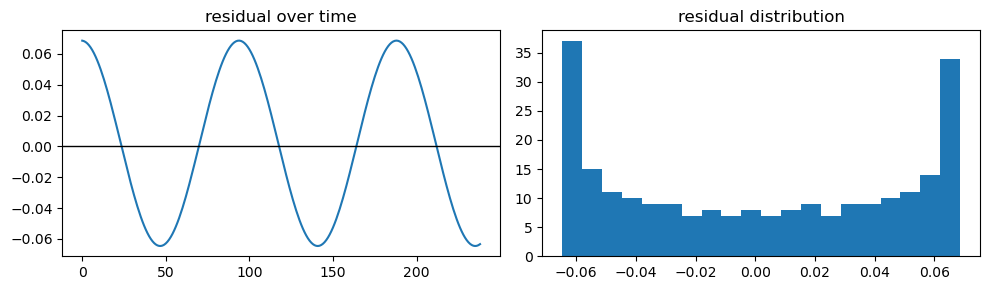

In [3]:
resid=actual-naive
fig,axes=plt.subplots(1,2,figsize=(10,3)); axes[0].plot(resid); axes[0].axhline(0,c="k",lw=1); axes[0].set_title("residual over time"); axes[1].hist(resid,bins=20); axes[1].set_title("residual distribution"); plt.tight_layout(); plt.show()


A neural forecast should beat a meaningful baseline. Aggregate metrics should be complemented by error slices over time/regime so systematic failure is visible.
